### 1. 데이터 불러오기 + 분류

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# 1. 데이터 불러오기
le_df = pd.read_csv('./data/cleaned_data.csv')
le_df.head()

,Country,Year,Status,Life_expectancy,Alcohol,Hepatitis_B,BMI,Polio,Diphtheria,HIV_AIDS,GDP,thinness _1_19_years,thinness_5_9_years,Iso_code,Region,Region_encoded,Schooling,Measles
0,Afghanistan,2000,0,54.8,0.01,62.0,12.2,24.0,24.0,0.1,114.560000,2.3,2.5,AFG,Asia,1,1.264052,27.0
1,Afghanistan,2001,0,55.3,0.01,63.0,12.6,35.0,33.0,0.1,117.496980,2.1,2.4,AFG,Asia,1,1.315551,37.0
2,Afghanistan,2002,0,56.2,0.01,64.0,13.0,36.0,36.0,0.1,187.845950,19.9,2.2,AFG,Asia,1,1.367049,35.0
3,Afghanistan,2003,0,56.7,0.01,65.0,13.4,41.0,41.0,0.1,198.728544,19.7,19.9,AFG,Asia,1,1.418548,39.0
4,Afghanistan,2004,0,57.0,0.02,95.0,13.8,95.0,95.0,0.1,219.141353,19.5,19.7,AFG,Asia,1,1.470046,48.0


In [15]:
# 2. 데이터 분리
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

target_column = 'Life_expectancy'
X = le_df.drop(target_column, axis=1)
y = le_df[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [16]:
le_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2766 entries, 0 to 2765
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               2766 non-null   object 
 1   Year                  2766 non-null   int64  
 2   Status                2766 non-null   int64  
 3   Life_expectancy       2766 non-null   float64
 4   Alcohol               2766 non-null   float64
 5   Hepatitis_B           2766 non-null   float64
 6   BMI                   2766 non-null   float64
 7   Polio                 2766 non-null   float64
 8   Diphtheria            2766 non-null   float64
 9   HIV_AIDS              2766 non-null   float64
 10  GDP                   2766 non-null   float64
 11  thinness _1_19_years  2766 non-null   float64
 12  thinness_5_9_years    2766 non-null   float64
 13  Iso_code              2766 non-null   object 
 14  Region                2766 non-null   object 
 15  Region_encoded       

### 2. 랜덤 포레스트

In [17]:
# 1. 불필요한 문자열 컬럼과 타겟 컬럼 제거
target = 'Life_expectancy'
cols_to_drop = ['Country', 'Iso_code', 'Region', 'Year', 'HIV_AIDS', target] # object인 것들 + object 다 제외하기

X = le_df.drop(cols_to_drop, axis=1) #cols_to_drop 제외한 나머지 열들을 feature로 취하는 것`
y = le_df[target]   #Life_expectancy

# 2. 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# 3. 올바른 모델 사용: Regressor (회귀)
rf_reg = RandomForestRegressor(max_depth=7, random_state=0)
rf_reg.fit(X_train, y_train)

# 4. 결과 확인 (R^2 Score)
print(f"학습 세트 점수: {rf_reg.score(X_train, y_train):.3f}")
print(f"테스트 세트 점수: {rf_reg.score(X_test, y_test):.3f}")

학습 세트 점수: 0.920
테스트 세트 점수: 0.881


In [18]:
rf_reg.estimators_samples_ #숫자 어레이 여러 개로 구성이 되어있음
len(rf_reg.estimators_samples_) 
len(rf_reg.estimators_samples_[0]) #426개
len(rf_reg.estimators_samples_[0]), len(rf_reg.estimators_samples_[10])

(2074, 2074)

In [19]:
# 1. 샘플 확인
# rf_reg가 제대로 학습(fit)되었다면 작동
print(len(rf_reg.estimators_samples_)) 
print(len(rf_reg.estimators_samples_[0]))

# 2. 특성 중요도(Feature Importance) 시리즈 만들기 [수정된 부분]
reg_le = pd.Series(rf_reg.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# 결과 출력
print(reg_le)

100
2074
Region_encoded          0.562229
Schooling               0.088740
Measles                 0.057681
GDP                     0.049081
Status                  0.047409
thinness_5_9_years      0.039375
BMI                     0.038327
Polio                   0.028037
Alcohol                 0.027865
Hepatitis_B             0.027164
thinness _1_19_years    0.018392
Diphtheria              0.015702
dtype: float64


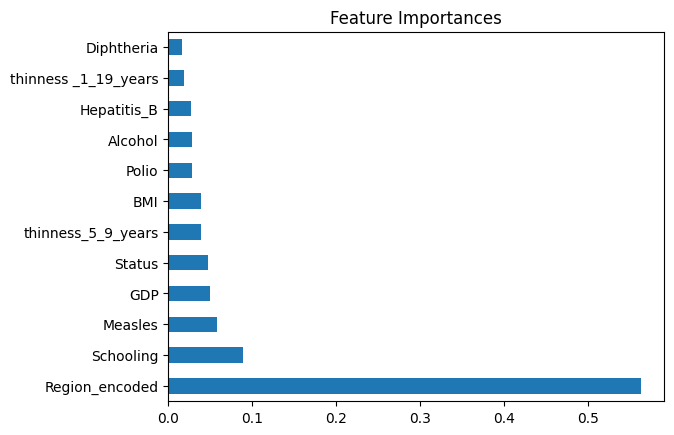

In [20]:
# 특성 중요도 시각화
reg_le.plot(kind='barh')
plt.title("Feature Importances")
plt.show()

### 3. RandomSearchCV

In [22]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# 1. 탐색할 파라미터 분포 설정
param_dist = {
    'n_estimators': randint(100, 500),      #tree의 개수: 많을 수록 좋지만 많으면 학습 속도가 느려짐
    'max_depth': randint(5, 20),            #tree의 깊이: 너무 깊으면 과대적합, 너무 얕으면 과소적합
    'min_samples_split': randint(2, 20),    #과적합 방지: 리프 노드에 최소한 몇 개의 데이터가 있어야 하는가?
    'min_samples_leaf': randint(1, 10),     #노드를 분할하기 위해 최소 몇 개의 데이터가 필요한가?
    'max_features': ['sqrt', 'log2', None] # None은 모든 피처 사용: 회귀에서는 전체 feature(1.0)이나 sqrt등을 비교해보는 게 좋음
}

# 2. RandomizedSearchCV 객체 생성
# n_iter=20 : 무작위로 20개의 조합만 시도
# n_jobs=-1 : 가능한 모든 CPU 코어를 사용해 속도를 높임
random_search = RandomizedSearchCV(
    estimator=rf_reg, 
    param_distributions=param_dist, 
    n_iter=50,
    cv=5, 
    scoring='r2', 
    random_state=42, 
    n_jobs=-1 
)

# 3. 학습 수행
random_search.fit(X_train, y_train)

# 4. 결과 확인
print(f"최적 파라미터: {random_search.best_params_}")
print(f"최고 R2 점수: {random_search.best_score_:.4f}")

# 5. 최적 모델로 테스트 데이터 평가
best_model = random_search.best_estimator_
test_score = best_model.score(X_test, y_test)
print(f"테스트 데이터 R2 점수: {test_score:.4f}")

최적 파라미터: {'max_depth': 19, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 149}
최고 R2 점수: 0.9072
테스트 데이터 R2 점수: 0.9197


In [23]:
print(random_search.best_params_)
print(random_search.best_estimator_)
print(random_search.best_score_)

{'max_depth': 19, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 149}
RandomForestRegressor(max_depth=19, max_features=None, min_samples_split=5,
                      n_estimators=149, random_state=0)
0.9072208958641863


In [24]:
# 1. RandomizedSearch가 찾아낸 '최적의 모델' 가져오기
best_rf_model = random_search.best_estimator_

# 2. 최적 모델로 예측 수행
y_pred_optimized = best_rf_model.predict(X_test)

# 3. 성능 지표 확인 (R2 Score 및 RMSE)
from sklearn.metrics import r2_score, mean_squared_error

final_r2 = r2_score(y_test, y_pred_optimized)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_optimized))

print("<최적화된 Random Forest 결과>")
print(f"최적 파라미터: {random_search.best_params_}")
print(f"최종 테스트 R2 Score: {final_r2:.4f}")
print(f"최종 테스트 RMSE: {final_rmse:.4f}")

<최적화된 Random Forest 결과>
최적 파라미터: {'max_depth': 19, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 149}
최종 테스트 R2 Score: 0.9197
최종 테스트 RMSE: 2.6209


In [25]:
# 2. 특성 중요도(Feature Importance) 시리즈 만들기 [수정된 부분]
best_rf_le = pd.Series(best_rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# 결과 출력
print(best_rf_le)

Region_encoded          0.519434
Schooling               0.092662
Measles                 0.060248
GDP                     0.055037
BMI                     0.046047
thinness_5_9_years      0.044177
Status                  0.042374
Alcohol                 0.037911
Polio                   0.028914
Hepatitis_B             0.028267
thinness _1_19_years    0.025738
Diphtheria              0.019191
dtype: float64


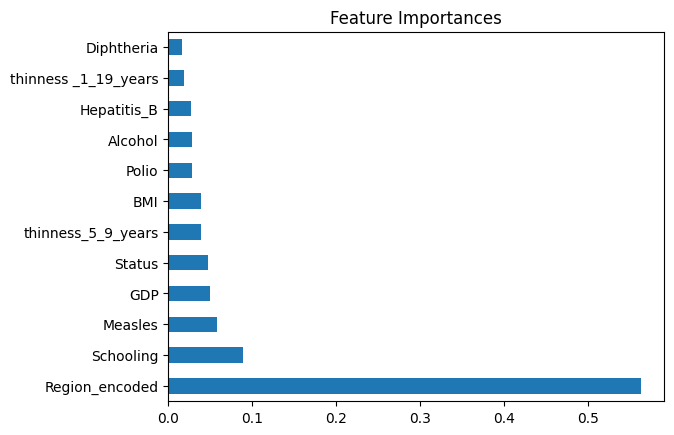

In [26]:
# 특성 중요도 시각화
reg_le.plot(kind='barh')
plt.title("Feature Importances")
plt.show()

In [27]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, mean_squared_log_error, root_mean_squared_log_error, r2_score
def evaluate_model(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    msle = mean_squared_log_error(y_true, y_pred)
    rmsle = root_mean_squared_log_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return pd.Series({'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MSLE': msle, 'RMSLE': rmsle, 'R2': r2}, name=name)

In [28]:
y_train_pred = rf_reg.predict(X_train)
y_test_pred = rf_reg.predict(X_test)

train_metrics = evaluate_model(y_train, y_train_pred, 'Train')
test_metrics = evaluate_model(y_test, y_test_pred, 'Test')

In [29]:
metrics_df = pd.DataFrame([train_metrics, test_metrics])
print(metrics_df.round(4))

           MSE    RMSE     MAE    MSLE   RMSLE      R2
Train   7.0558  2.6563  1.9415  0.0017  0.0414  0.9204
Test   10.1668  3.1885  2.3546  0.0024  0.0494  0.8812


### 4. Optuna

In [30]:
import optuna
from optuna import visualization

def objective(trial):
    # 1. 탐색할 하이퍼파라미터 범위 설정
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),         # 트리의 개수
        'max_depth': trial.suggest_int('max_depth', 3, 30),                 # 트리의 최대 깊이
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20), # 노드 분할을 위한 최소 샘플 수
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),   # 리프 노드가 되기 위한 최소 샘플 수
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]), # 피처 고려 방식
        'random_state': 42,
        'n_jobs': -1  # 병렬 처리
    }

    # 2. 모델 학습
    model = RandomForestRegressor(**param)
    model.fit(X_train, y_train)

    # 3. 예측 및 평가 (여기서는 RMSE를 최소화하는 것을 목표로 설정)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    return rmse

# Optuna 최적화 실행
# direction='minimize': RMSE는 낮을수록 좋으므로 minimize 설정
study = optuna.create_study(direction='minimize', study_name='RF_Optimization')
study.optimize(objective, n_trials=50) # n_trials: 시도할 횟수 (횟수가 많을수록 더 좋은 값을 찾을 확률이 높음)

print('Best trial:', study.best_trial.params)
print('Best RMSE:', study.best_value)

[I 2026-02-10 19:07:13,672] A new study created in memory with name: RF_Optimization
[I 2026-02-10 19:07:13,867] Trial 0 finished with value: 2.965502954024701 and parameters: {'n_estimators': 78, 'max_depth': 19, 'min_samples_split': 18, 'min_samples_leaf': 3, 'max_features': None}. Best is trial 0 with value: 2.965502954024701.
[I 2026-02-10 19:07:14,039] Trial 1 finished with value: 3.1164255440017308 and parameters: {'n_estimators': 82, 'max_depth': 19, 'min_samples_split': 12, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 0 with value: 2.965502954024701.
[I 2026-02-10 19:07:14,767] Trial 2 finished with value: 2.9303975252551555 and parameters: {'n_estimators': 481, 'max_depth': 16, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 2 with value: 2.9303975252551555.
[I 2026-02-10 19:07:15,069] Trial 3 finished with value: 3.1380802140782866 and parameters: {'n_estimators': 227, 'max_depth': 19, 'min_samples_split': 19, 'min_sample

Best trial: {'n_estimators': 300, 'max_depth': 20, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': None}
Best RMSE: 2.5856229597311042
